<a href="https://colab.research.google.com/github/aluongleekalierleek/Lab_3/blob/main/Lab_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# You will import the specific sklearn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)   # use this everywhere so your results are reproducible
np.random.seed(RANDOM_STATE)

print("Running on:", DEVICE)

Running on: cpu


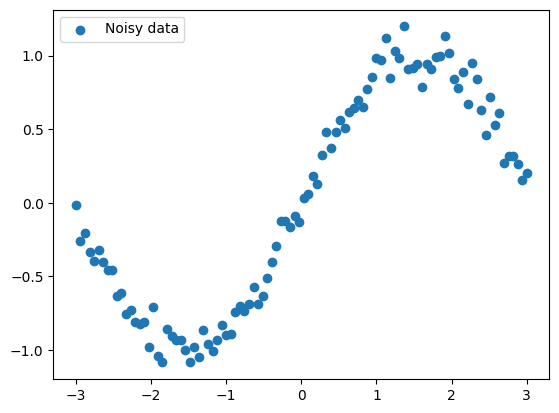

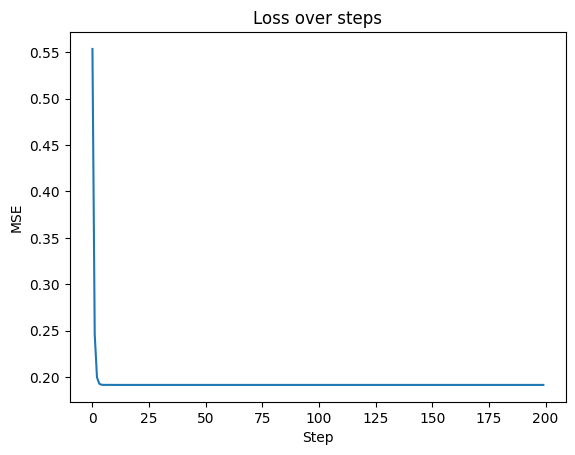

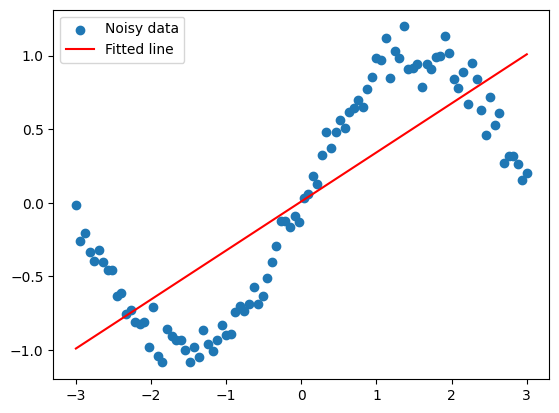

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Generate toy data
x = np.linspace(-3, 3, 100)
y = np.sin(x) + np.random.normal(0, 0.1, size=x.shape)  # sine + Gaussian noise

plt.scatter(x, y, label="Noisy data")
plt.legend()
plt.show()

# 2. Initialize parameters
w = np.random.randn() * 0.01   # small random weight
b = np.random.randn() * 0.01   # small random bias
lr = 0.1                       # learning rate

# 3. Gradient descent loop
losses = []
for step in range(200):
    y_hat = w * x + b
    loss = np.mean((y_hat - y) ** 2)
    losses.append(loss)

    # Gradients
    dw = np.mean(2 * (y_hat - y) * x)   # dLoss/dw
    db = np.mean(2 * (y_hat - y))       # dLoss/db

    # Update
    w -= lr * dw
    b -= lr * db

# 4. Plot results
# (a) Loss curve
plt.plot(losses)
plt.title("Loss over steps")
plt.xlabel("Step")
plt.ylabel("MSE")
plt.show()

# (b) Data with fitted line
plt.scatter(x, y, label="Noisy data")
plt.plot(x, w * x + b, color="red", label="Fitted line")
plt.legend()
plt.show()


**my reasoning: The single neuron**

1. Gradient:  
Loss = mean((y_hat - y)^2).  
So dLoss/dw = mean(2 * (y_hat - y) * x).  
And dLoss/db = mean(2 * (y_hat - y)).  
This is the same as in my code.

2. Fit:  
The loss goes down, but the line does not match the sine curve.  
This is underfitting because one straight line cannot follow the wave.  
A single neuron is only linear, so it can never learn sine.  
We need more layers and nonlinear functions to fit curves.




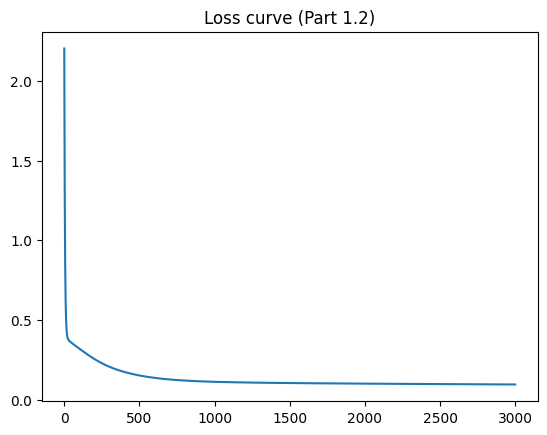

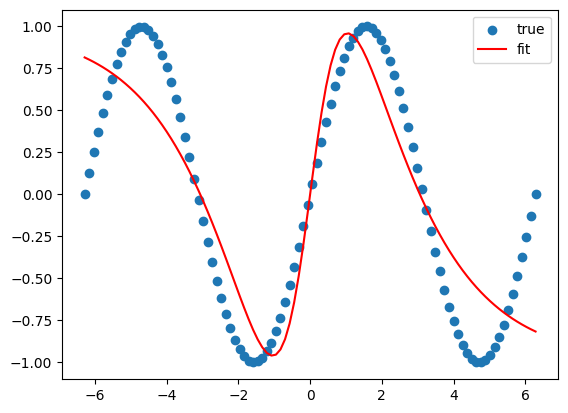

In [8]:
##part 1.2
import numpy as np
import matplotlib.pyplot as plt

# Data
x = np.linspace(-2*np.pi, 2*np.pi, 100).reshape(-1,1)
y = np.sin(x)

# Parameters
np.random.seed(0)
W1 = np.random.randn(1,8) * 0.5
b1 = np.zeros(8)
W2 = np.random.randn(8,1) * 0.5
b2 = np.zeros(1)

lr = 0.01
losses = []

# Training loop
for step in range(3000):
    # Forward
    z1 = x @ W1 + b1
    h = np.tanh(z1)
    y_hat = h @ W2 + b2
    loss = np.mean((y_hat - y)**2)
    losses.append(loss)

    # Backward
    d_yhat = 2*(y_hat - y)/len(y)
    dW2 = h.T @ d_yhat
    db2 = d_yhat.sum(axis=0)
    dh = d_yhat @ W2.T
    dz1 = dh * (1 - np.tanh(z1)**2)
    dW1 = x.T @ dz1
    db1 = dz1.sum(axis=0)

    # Update
    W1 -= lr*dW1
    b1 -= lr*db1
    W2 -= lr*dW2
    b2 -= lr*db2

# Plot loss
plt.plot(losses)
plt.title("Loss curve (Part 1.2)")
plt.show()

# Plot fit
plt.scatter(x,y,label="true")
plt.plot(x,y_hat,label="fit",color="red")
plt.legend()
plt.show()


**My Reasoning: Depth and activations**

1. If we remove tanh, the network is only linear on top of linear. A chain of linear layers is still just one line. That is why the fit looks the same as Part 1.1.

2. With tanh, the hidden layer makes curved features. Each of the 8 neurons learns a different curve. When we add them together, they can follow the sine wave much better.

3. Backpropagation is the chain rule used step by step to find gradients for all layers.
